In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import os
import numpy as np

------

Loading the cleaned data, extracting and creating datasets specifically for EMERALDS

------

In [13]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
day1_prices = pd.read_csv("/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Cleaned_Data/day1_prices.csv")
day1_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread
0,-1,0,TOMATOES,4999,5,4998,15,5013,5,5014,15,5006.0,0.0,14
1,-1,0,EMERALDS,9992,14,9990,29,10008,14,10010,29,10000.0,0.0,16
2,-1,100,EMERALDS,9992,11,9990,22,10008,11,10010,22,10000.0,0.0,16
3,-1,100,TOMATOES,5000,8,4998,21,5013,8,5014,21,5006.5,0.0,13
4,-1,200,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0,16


In [4]:
day2_prices = pd.read_csv("/Users/sudhanvabharadwaj/Downloads/IMC_Prosperity4/Cleaned_Data/day2_prices.csv")
day2_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread
0,-2,0,EMERALDS,9992,11,9990,25,10008,11,10010,25,10000.0,0.0,16
1,-2,0,TOMATOES,4993,7,4992,17,5007,7,5008,17,5000.0,0.0,14
2,-2,100,TOMATOES,4998,5,4993,7,5007,7,5008,16,5002.5,0.0,9
3,-2,100,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0,16
4,-2,200,TOMATOES,4994,6,4993,20,5008,6,5009,20,5001.0,0.0,14


In [6]:
day1_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread
0,-1,0,TOMATOES,4999,5,4998,15,5013,5,5014,15,5006.0,0.0,14
1,-1,0,EMERALDS,9992,14,9990,29,10008,14,10010,29,10000.0,0.0,16
2,-1,100,EMERALDS,9992,11,9990,22,10008,11,10010,22,10000.0,0.0,16
3,-1,100,TOMATOES,5000,8,4998,21,5013,8,5014,21,5006.5,0.0,13
4,-1,200,EMERALDS,9992,15,9990,20,10008,15,10010,20,10000.0,0.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-1,999700,EMERALDS,9992,12,9990,26,10008,12,10010,26,10000.0,0.0,16
19996,-1,999800,EMERALDS,9992,13,9990,20,10008,13,10010,20,10000.0,0.0,16
19997,-1,999800,TOMATOES,4951,6,4949,18,4964,6,4965,18,4957.5,0.0,13
19998,-1,999900,TOMATOES,4950,10,4949,25,4964,10,4965,25,4957.0,0.0,14


-----

In [9]:
emeralds1 = day1_prices[day1_prices['product'] == 'EMERALDS']

emeralds1.select_dtypes(include='number').agg(['mean', 'std', 'min', 'max']).T

,mean,std,min,max
day,-1.0000,0.000000,-1.0,-1.0
timestamp,499950.0000,288689.567991,0.0,999900.0
bid_price_1,9992.1264,0.997659,9992.0,10000.0
bid_volume_1,12.4570,1.814519,5.0,15.0
bid_price_2,9990.0316,0.249415,9990.0,9992.0
bid_volume_2,24.7815,3.515849,10.0,30.0
ask_price_1,10007.8696,1.013064,10000.0,10008.0
ask_volume_1,12.4627,1.808075,5.0,15.0
ask_price_2,10009.9674,0.253266,10008.0,10010.0
ask_volume_2,24.7673,3.543925,10.0,30.0


In [10]:
emeralds2 = day2_prices[day2_prices['product'] == 'EMERALDS']

emeralds2.select_dtypes(include='number').agg(['mean', 'std', 'min', 'max']).T

,mean,std,min,max
day,-2.0000,0.000000,-2.0,-2.0
timestamp,499950.0000,288689.567991,0.0,999900.0
bid_price_1,9992.1304,1.013064,9992.0,10000.0
bid_volume_1,12.4571,1.825786,5.0,15.0
bid_price_2,9990.0326,0.253266,9990.0,9992.0
bid_volume_2,24.8366,3.533829,10.0,30.0
ask_price_1,10007.8640,1.034220,10000.0,10008.0
ask_volume_1,12.4569,1.822436,5.0,15.0
ask_price_2,10009.9660,0.258555,10008.0,10010.0
ask_volume_2,24.8320,3.552723,10.0,30.0


-----

In-Depth analysis of order book data

------

1. Imbalance

In [ ]:
emeralds1['imbalance'] = (emeralds1['bid_volume_1'] - emeralds1['ask_volume_1']) / (emeralds1['bid_volume_1'] + emeralds1['ask_volume_1'])

emeralds1['imbalance'].describe()

count    10000.000000
mean        -0.000281
std          0.049652
min         -0.500000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.500000
Name: imbalance, dtype: float64

In [16]:
emeralds2['imbalance'] = (emeralds1['bid_volume_1'] - emeralds1['ask_volume_1']) / (emeralds1['bid_volume_1'] + emeralds1['ask_volume_1'])

emeralds2['imbalance'].describe()

count    2518.000000
mean       -0.000214
std         0.049147
min        -0.500000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.473684
Name: imbalance, dtype: float64

----

2. Micro price

In [17]:
# Micro price 

emeralds1['micro_price'] = (emeralds1['bid_price_1'] * emeralds1['ask_volume_1'] + emeralds1['ask_price_1'] * emeralds1['bid_volume_1']) / (emeralds1['bid_volume_1'] + emeralds1['ask_volume_1'])

emeralds1['micro_price'].describe()

count    10000.000000
mean      9999.996875
std          0.545541
min       9996.000000
25%      10000.000000
50%      10000.000000
75%      10000.000000
max      10004.000000
Name: micro_price, dtype: float64

In [18]:
# Micro price 

emeralds2['micro_price'] = (emeralds2['bid_price_1'] * emeralds2['ask_volume_1'] + emeralds2['ask_price_1'] * emeralds2['bid_volume_1']) / (emeralds2['bid_volume_1'] + emeralds2['ask_volume_1'])

emeralds2['micro_price'].describe()

count    10000.000000
mean      9999.997077
std          0.560937
min       9996.000000
25%      10000.000000
50%      10000.000000
75%      10000.000000
max      10004.000000
Name: micro_price, dtype: float64

In [22]:
(emeralds1['micro_price'] > emeralds1['mid_price']).mean()

np.float64(0.0158)

In [27]:
(emeralds2['micro_price'] > emeralds2['mid_price']).mean()

np.float64(0.0169)

------

3. Plots and Distributions

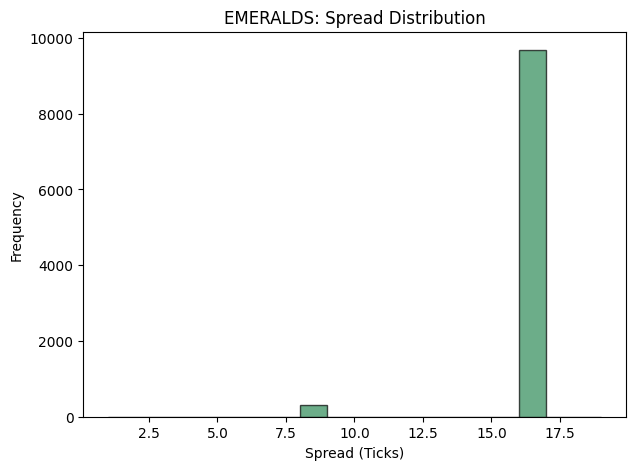

In [ ]:
import matplotlib.pyplot as plt

emeralds_spread1 = emeralds1['spread']

plt.figure(figsize=(7, 5))
plt.hist(emeralds_spread, bins=range(1, 20), color='seagreen', edgecolor='black', alpha=0.7)

plt.title('EMERALDS: Spread Distribution')
plt.xlabel('Spread (Ticks)')
plt.ylabel('Frequency')

plt.show()

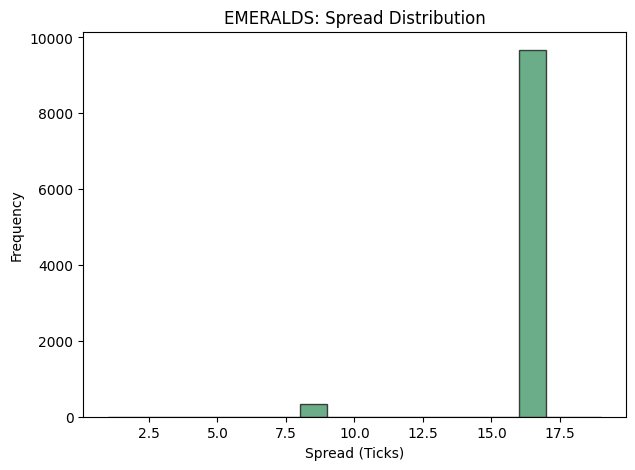

In [29]:
import matplotlib.pyplot as plt

emeralds_spread2 = emeralds2['spread']

plt.figure(figsize=(7, 5))
plt.hist(emeralds_spread2, bins=range(1, 20), color='seagreen', edgecolor='black', alpha=0.7)

plt.title('EMERALDS: Spread Distribution')
plt.xlabel('Spread (Ticks)')
plt.ylabel('Frequency')

plt.show()

In [33]:
# Calculate the percentage of time the spread is at the minimum observed value
def get_spread_stats(df):
    
    min_s = df['spread'].min()
    pct_min = (df['spread'] == min_s).mean() * 100
    return pd.Series({
        'Min Spread': min_s,
        '% Time at Min': f"{pct_min:.2f}%",
        'Max Spread': df['spread'].max(),
        'Avg Spread': df['spread'].mean()
    })

spread_analysis = get_spread_stats(emeralds1)
spread_analysis

Min Spread             8
% Time at Min      3.21%
Max Spread            16
Avg Spread       15.7432
dtype: object

In [34]:
# Calculate the percentage of time the spread is at the minimum observed value
def get_spread_stats(df):
    
    min_s = df['spread'].min()
    pct_min = (df['spread'] == min_s).mean() * 100
    return pd.Series({
        'Min Spread': min_s,
        '% Time at Min': f"{pct_min:.2f}%",
        'Max Spread': df['spread'].max(),
        'Avg Spread': df['spread'].mean()
    })

spread_analysis = get_spread_stats(emeralds2)
spread_analysis

Min Spread             8
% Time at Min      3.33%
Max Spread            16
Avg Spread       15.7336
dtype: object

In [35]:
# Calculate the percentage of time the spread is at the minimum observed value
def get_spread_stats(df):
    
    max_s = df['spread'].max()
    pct_max = (df['spread'] == max_s).mean() * 100
    return pd.Series({
        'Max Spread': max_s,
        '% Time at Max': f"{pct_max:.2f}%",
        'Min Spread': df['spread'].min(),
        'Avg Spread': df['spread'].mean()
    })

spread_analysis = get_spread_stats(emeralds1)

spread_analysis

Max Spread            16
% Time at Max     96.79%
Min Spread             8
Avg Spread       15.7432
dtype: object

In [36]:
# Calculate the percentage of time the spread is at the minimum observed value
def get_spread_stats(df):
    
    max_s = df['spread'].max()
    pct_max = (df['spread'] == max_s).mean() * 100
    return pd.Series({
        'Max Spread': max_s,
        '% Time at Max': f"{pct_max:.2f}%",
        'Min Spread': df['spread'].min(),
        'Avg Spread': df['spread'].mean()
    })

spread_analysis = get_spread_stats(emeralds2)

spread_analysis

Max Spread            16
% Time at Max     96.67%
Min Spread             8
Avg Spread       15.7336
dtype: object

-----

4. Fair value stability

In [37]:
emeralds1.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'ask_price_1', 'ask_volume_1',
       'ask_price_2', 'ask_volume_2', 'mid_price', 'profit_and_loss', 'spread',
       'imbalance', 'micro_price', 'micro_mid_diff'],
      dtype='object')

In [38]:
emeralds2.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'ask_price_1', 'ask_volume_1',
       'ask_price_2', 'ask_volume_2', 'mid_price', 'profit_and_loss', 'spread',
       'imbalance', 'micro_price'],
      dtype='object')

In [41]:
emeralds1.shape

(10000, 17)

In [45]:
emeralds1_10k = emeralds1[(emeralds1['mid_price'] == 10000)]
emeralds1_10k.shape

(9679, 17)

In [46]:
emeralds1_10k.describe()

,day,timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread,imbalance,micro_price,micro_mid_diff
count,9679.0,9679.000000,9679.0,9679.000000,9679.0,9679.000000,9679.0,9679.000000,9679.0,9679.000000,9679.0,9679.0,9679.0,9679.0,9679.0,9679.0
mean,-1.0,499813.679099,9992.0,12.543135,9990.0,24.975927,10008.0,12.543135,10010.0,24.975927,10000.0,0.0,16.0,0.0,10000.0,0.0
std,0.0,288553.002354,0.0,1.698733,0.0,3.174041,0.0,1.698733,0.0,3.174041,0.0,0.0,0.0,0.0,0.0,0.0
min,-1.0,0.000000,9992.0,10.000000,9990.0,20.000000,10008.0,10.000000,10010.0,20.000000,10000.0,0.0,16.0,0.0,10000.0,0.0
25%,-1.0,249850.000000,9992.0,11.000000,9990.0,22.000000,10008.0,11.000000,10010.0,22.000000,10000.0,0.0,16.0,0.0,10000.0,0.0
50%,-1.0,501000.000000,9992.0,13.000000,9990.0,25.000000,10008.0,13.000000,10010.0,25.000000,10000.0,0.0,16.0,0.0,10000.0,0.0
75%,-1.0,749450.000000,9992.0,14.000000,9990.0,28.000000,10008.0,14.000000,10010.0,28.000000,10000.0,0.0,16.0,0.0,10000.0,0.0
max,-1.0,999900.000000,9992.0,15.000000,9990.0,30.000000,10008.0,15.000000,10010.0,30.000000,10000.0,0.0,16.0,0.0,10000.0,0.0


In [43]:
emeralds1_10k = emeralds1[(emeralds1['mid_price'] < 10000) | (emeralds1['mid_price'] > 100000)]
emeralds1_10k.shape

(163, 17)

In [44]:
emeralds1_10k.describe()

,day,timestamp,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,profit_and_loss,spread,imbalance,micro_price,micro_mid_diff
count,163.0,163.000000,163.0,163.000000,163.0,163.000000,163.0,163.000000,163.0,163.000000,163.0,163.0,163.0,163.000000,163.000000,163.000000
mean,-1.0,512057.668712,9992.0,12.220859,9990.0,25.110429,10000.0,7.619632,10008.0,12.220859,9996.0,0.0,8.0,0.236240,9996.944961,0.944961
std,0.0,290057.948637,0.0,1.587080,0.0,3.138778,0.0,1.693155,0.0,1.587080,0.0,0.0,0.0,0.120514,0.482057,0.482057
min,-1.0,2800.000000,9992.0,10.000000,9990.0,20.000000,10000.0,5.000000,10008.0,10.000000,9996.0,0.0,8.0,0.000000,9996.000000,0.000000
25%,-1.0,280300.000000,9992.0,11.000000,9990.0,22.500000,10000.0,6.000000,10008.0,11.000000,9996.0,0.0,8.0,0.157895,9996.631579,0.631579
50%,-1.0,472200.000000,9992.0,12.000000,9990.0,25.000000,10000.0,8.000000,10008.0,12.000000,9996.0,0.0,8.0,0.222222,9996.888889,0.888889
75%,-1.0,774200.000000,9992.0,14.000000,9990.0,28.000000,10000.0,9.000000,10008.0,14.000000,9996.0,0.0,8.0,0.333333,9997.333333,1.333333
max,-1.0,995800.000000,9992.0,15.000000,9990.0,30.000000,10000.0,10.000000,10008.0,15.000000,9996.0,0.0,8.0,0.500000,9998.000000,2.000000
